# Trenowanie modelu

Notebook łączący tworzenie modelu oraz proces jego trenowania.
Obejmuje przygotowanie danych wejściowych, inicjalizację modelu,
jego kompilację, trening oraz zapis finalnego artefaktu.

## Setup środowiska

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
%run /content/drive/MyDrive/Project-PSI/src/utils/setup

In [46]:
%run /content/drive/MyDrive/Project-PSI/notebooks/02_dataset.ipynb
%run /content/drive/MyDrive/Project-PSI/notebooks/03_model.ipynb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
90 9637016
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (64, None)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (64, None, 512)        │        46,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (64, None, 2048)       │    20,979,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, None, 90)         │       184,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,210,202 (80.91 MB)

 Trainable params: 21,210,202 (80.91 MB)

 Non-trainable params: 0 (0.00 B)

## Trening modelu

### Import komponentów treningowych

In [49]:
from src.models.train import (
    get_checkpoint_callback,
    train_model,
    save_final_model
)
from src.utils.paths import CHECKPOINTS_DIR, FINAL_MODELS_DIR, METRICS_DIR

### Callback Checkpoint

In [5]:
checkpoint = get_checkpoint_callback(CHECKPOINTS_DIR)

### Uruchomienie treningu

In [6]:
history = train_model(
    model,
    dataset,
    checkpoint,
    epochs=10
)

Epoch 1/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 476s 316ms/step - loss: 1.5470
Epoch 2/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 483s 323ms/step - loss: 1.2113
Epoch 3/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 483s 323ms/step - loss: 1.1490
Epoch 4/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 484s 323ms/step - loss: 1.1107
Epoch 5/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 483s 323ms/step - loss: 1.0811
Epoch 6/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 482s 322ms/step - loss: 1.0559
Epoch 7/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 482s 322ms/step - loss: 1.0352
Epoch 8/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 484s 323ms/step - loss: 1.0171
Epoch 9/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 484s 323ms/step - loss: 1.0023
Epoch 10/10
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 483s 323ms/step - loss: 0.9904


### Zapis modelu

In [7]:
save_final_model(
    model,
    FINAL_MODELS_DIR / "asoiaf_10_512_2048.keras"
)

PosixPath('/content/drive/MyDrive/Project-PSI/models/final/asoiaf_10_512_2048.keras')

### Importy do wizualizacji

In [65]:
import matplotlib.pyplot as plt
import numpy as np

from src.evaluation.metrics import history_to_metrics

### Przygotowanie wizualizacji

In [67]:
metrics = history_to_metrics(history)

### Wizualizacje wyników

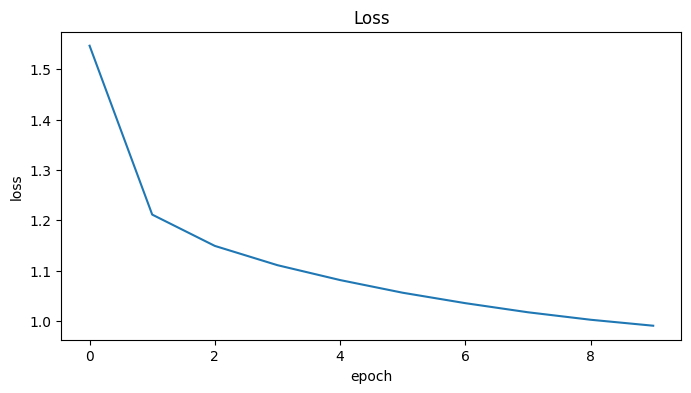

Loss: [1.5469878911972046, 1.2112687826156616, 1.1490451097488403, 1.1107208728790283, 1.081140398979187, 1.0559464693069458, 1.0352200269699097, 1.017111897468567, 1.002258062362671, 0.9903799295425415]


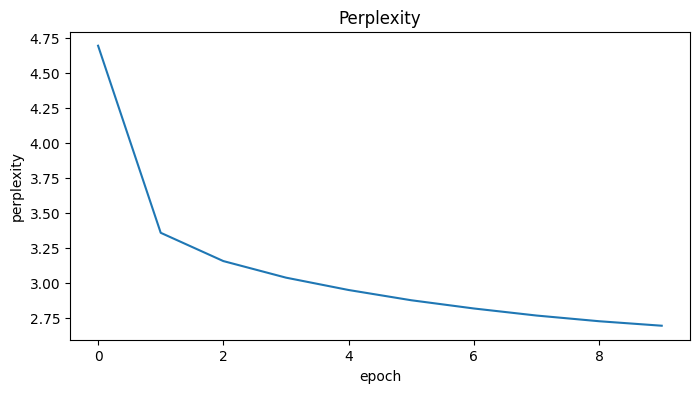

Perplexity: [4.697300073448439, 3.357742195955443, 3.1551786214552875, 3.036546569710823, 2.9480395761400287, 2.874694677004385, 2.815725703066335, 2.765197047817629, 2.7244268136158443, 2.6922571460908955]


In [68]:
plt.figure(figsize=(8, 4))
plt.plot(metrics['loss'])
plt.title('Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()
print("Loss:", metrics["loss"])

plt.figure(figsize=(8, 4))
plt.plot(metrics['perplexity'])
plt.title('Perplexity')
plt.ylabel('perplexity')
plt.xlabel('epoch')
plt.show()
print("Perplexity:", metrics["perplexity"])